# Multi-objective shape optimisation

A small evolutionary run over an elliptical mid-cell: each candidate is tuned to a target frequency, then ranked by two conflicting objectives — peak surface **electric** field and peak surface **magnetic** field (both normalised to the accelerating gradient). The result is a Pareto front of the best trade-offs.

The optimisation template is whatever cavity you add to the study, so the same workflow optimises any model (pillbox, RF-gun, spline, ...).

See the [optimisation guide](../../optimisation). Kept tiny (a handful of candidates, one generation) so it runs in a couple of minutes.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import Cavities, EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

## 1. The study and the search space

`bounds` are the swept design variables; the tuned handle (`Req`, via `cell_type`) is adjusted separately to keep every candidate on frequency, so it is *not* one of the bounds.

In [2]:
cavs = Cavities(os.path.join(tempfile.mkdtemp(), 'opt'))
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]
cavs.add_cavity([EllipticalCavity(1, midcell, midcell, midcell, beampipe='none')], ['TESLA'])

config = {
    'initial_points': 4,
    'no_of_generation': 1,
    'method': {'LHS': {'seed': 5}},
    'bounds': {'A': [40, 46], 'B': [40, 46], 'a': [10, 14], 'b': [17, 21]},
    'objectives': [['min', 'monopole:Epk/Eacc []'],
                   ['min', 'monopole:Bpk/Eacc [mT/MV/m]']],
    'tune_config': {
        'freqs': 1300.0,
        'cell_type': {'mid-cell': 'Req'},
        'processes': 1,
        'eigenmode_config': {'n_cells': 1, 'processes': 1, 'boundary_conditions': 'mm'},
    },
    'mutation_factor': 4, 'crossover_factor': 4, 'elites_for_crossover': 2,
    'chaos_factor': 2, 'weights': [1, 1],
}

## 2. Run the optimisation

In [3]:
cavs.run_optimisation(config)
opt = cavs.optimisation
print(f'evaluated candidates: {len(opt.history)}')
print(f'Pareto-front size:    {len(opt.pareto)}')

  0%|          | 0/1 [00:00<?, ?it/s]

ERROR:: Done Tuning Cavity G0_C0_P [mid-cell: Req_m]: Failed: Accuracy of 1.00e-04 could not be reached. Accuracy of 4.55e-04 reached.


ERROR:: Done Tuning Cavity G0_C1_P [mid-cell: Req_m]: Failed: Accuracy of 1.00e-04 could not be reached. Accuracy of 4.55e-04 reached.


ERROR:: Done Tuning Cavity G0_C2_P [mid-cell: Req_m]: Failed: Accuracy of 1.00e-04 could not be reached. Accuracy of 4.55e-04 reached.


ERROR:: Done Tuning Cavity G0_C3_P [mid-cell: Req_m]: Failed: Accuracy of 1.00e-04 could not be reached. Accuracy of 4.55e-04 reached.


100%|██████████| 1/1 [00:50<00:00, 50.46s/it]

evaluated candidates: 4
Pareto-front size:    2


## 3. The Pareto front

Each point is a candidate in objective space; the front is the set of non-dominated trade-offs (lowering one peak field costs the other).

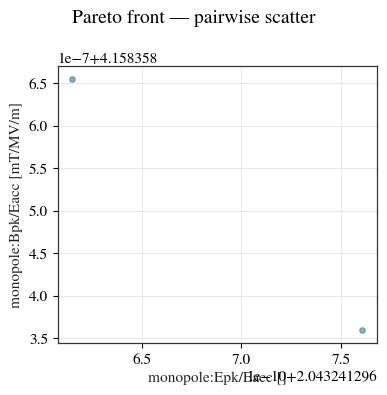

In [4]:
opt.plot_pareto(kind='scatter', normalise=False)
plt.show()

The full evaluated history (Pareto set highlighted):

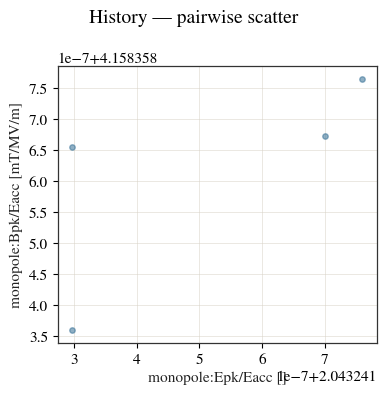

In [5]:
opt.plot_history(kind='scatter', normalise=False)
plt.show()

## Where to go next

- Add more generations (`no_of_generation`) and candidates (`initial_points`) for a real run.
- Swap the template cavity for a `Pillbox`, `RFGun` or `SplineCavity` and give bounds in that model's own variables — the workflow is identical.